## MS Disease Progression: A Network Delay Perspective

This notebook models the progressive neural network changes associated with Multiple Sclerosis (MS) 
using the Wilson-Cowan metapopulation DDE framework (Conti & Van Gorder, 2019), extended with 
heterogeneous delay structure (Atay & Hutt, 2006).

MS is a demyelinating disease of the central nervous system characterised by progressive degradation 
of the myelin sheath surrounding axons. This has direct consequences for neural signal transmission:

- **Demyelination** reduces and destabilises axonal conduction velocity
- **Axonal loss** in advanced stages permanently disrupts network connectivity

We model these effects through three mechanisms already present in our delay framework:
1. Reduced mean conduction velocity (vm)
2. Increased heterogeneity in conduction velocities (lower shape parameter p)
3. Random edge removal to simulate axonal loss (stage 3 only)

We track how these progressive changes affect oscillatory dynamics across four network topologies, 
asking: does network architecture determine vulnerability to MS-related dynamic disruption?

### References
- Compston & Coles (2008) - Multiple sclerosis. Lancet.
- Waxman (2006) - Ions, energy and axonal injury. Trends in Neurosciences.
- Bjartmar & Trapp (2001) - Axonal and neuronal degeneration in MS. Current Opinion in Neurology.
- Atay & Hutt (2006) - Neural fields with distributed transmission speeds. SIAM Journal.
- Conti & Van Gorder (2019) - Network structure and time delay in Wilson-Cowan model. JTB.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

sys.path.append(os.path.abspath(".."))

from src.metapopulation import Metapopulation
from src.delays import heterogeneous_delay_matrix
from src.ms_progression import remove_edges, get_stage_params, MS_STAGES, REMOVAL_RATES

CONFIG = os.path.join(os.path.dirname(os.path.abspath("__file__")), "distance_delays.yaml")
TOPOLOGIES = ['line', 'full', 'ring', 'lattice']
N = 16
SEED = 42

### MS Staging Parameters

We model four stages of MS progression based on established literature values:

| Stage | Description | vm (m/s) | p (shape) | Axonal Loss |
|-------|-------------|----------|-----------|-------------|
| 0 | Healthy baseline | 6.0 | 10.0 | None |
| 1 | Early MS: focal demyelination | 4.0 | 4.5 | None |
| 2 | Moderate MS: widespread demyelination | 2.0 | 2.5 | None |
| 3 | Severe MS: axonal loss | 2.0 | 2.5 | Yes |

**vm** is the mode of the Gamma-distributed conduction velocity (Atay & Hutt, 2006, eq. 5.2). 
Waxman (2006) reports 40-50% reduction in conduction velocity in demyelinated axons, motivating 
the progression from 6.0 to 4.0 to 2.0 m/s.

**p** is the shape parameter of the Gamma distribution. Lower p means broader distribution - 
more heterogeneous myelination across axon tracts. In healthy tissue, myelination is relatively 
uniform (high p). MS causes patchy demyelination, increasing heterogeneity (lower p).

**Axonal loss rates for stage 3:**
- Line: 0% (too sparse - any removal fragments network, itself a finding)
- Full: 30% random removal (Bjartmar & Trapp, 2001)
- Ring: 20% random removal
- Lattice: 25% random removal

All stages use target_mean_rho=10 to keep mean delay fixed, isolating the effect of 
heterogeneity and connectivity changes from mean delay magnitude.

In [2]:
df_stages = pd.DataFrame([
    {
        'Stage': stage,
        'Description': params['description'],
        'vm (m/s)': params['vm'],
        'p (shape)': params['p'],
        'Axonal Loss': 'Yes' if stage == 3 else 'No'
    }
    for stage, params in MS_STAGES.items()
])
display(df_stages)

print("\nEdge removal rates for stage 3:")
df_removal = pd.DataFrame([
    {'Topology': t, 'Removal Rate': f"{int(r*100)}%", 'Edges removed (N=16)': 'N/A - too sparse' if r==0 else 'random'}
    for t, r in REMOVAL_RATES.items()
])
display(df_removal)

,Stage,Description,vm (m/s),p (shape),Axonal Loss
0,0,Healthy baseline,6.0,10.0,No
1,1,Early MS: focal demyelination,4.0,4.5,No
2,2,Moderate MS: widespread demyelination,2.0,2.5,No
3,3,Severe MS: axonal loss,2.0,2.5,Yes



Edge removal rates for stage 3:


,Topology,Removal Rate,Edges removed (N=16)
0,line,0%,N/A - too sparse
1,full,30%,random
2,ring,20%,random
3,lattice,25%,random


In [8]:
def run_stage(topology, stage, seed=SEED):
    """Run simulation for a given topology and MS stage."""
    params = get_stage_params(stage)
    
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': topology, 'N': N})
    
    # Stage 3: remove edges first
    if stage == 3:
        n_removed = remove_edges(m.network, topology, seed=seed)
        print(f"  {topology}: removed {n_removed} edges")
    
    m.create_delay_matrix(
        mode='heterogeneous',
        vm=params['vm'],
        p=params['p'],
        target_mean_rho=10.0,
        seed=seed
    )
    m.initialise_model()
    m.run_simulation()
    return m


def get_synchrony(trajectories, t_array, t_start=20):
    mask = t_array >= t_start
    E = trajectories[0][:, mask]
    return float(np.mean(np.var(E, axis=0)))


def get_frequency(trajectories, t_array, dt=0.1, t_start=20):
    mask = t_array >= t_start
    E = trajectories[0][:, mask]
    freqs = np.fft.rfftfreq(E.shape[1], d=dt)
    fft_power = np.abs(np.fft.rfft(E, axis=1))
    fft_power[:, 0] = 0
    fft_mean = np.mean(fft_power, axis=0)
    return float(freqs[np.argmax(fft_mean)])


def plot_stage(results, stage, t_start=25):
    """Plot trajectories and delay matrices for all topologies at a given stage."""
    fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(18, 8))
    fig.suptitle(f"Stage {stage}: {MS_STAGES[stage]['description']}")
    
    for i, topology in enumerate(TOPOLOGIES):
        m = results[(topology, stage)]
        t = m.model.time_array
        mask = t >= t_start
        
        # Trajectory
        axes[0, i].plot(t[mask], m.model.trajectories[0][:, mask].T, 
                       color='blue', alpha=0.5, linewidth=0.8)
        axes[0, i].plot(t[mask], m.model.trajectories[1][:, mask].T, 
                       color='black', alpha=0.5, linewidth=0.8)
        axes[0, i].set_title(topology)
        axes[0, i].set_ylim(0, 1)
        axes[0, i].set_xlabel("Time (ms)")
        if i == 0:
            axes[0, i].set_ylabel("Activity")
        
        # Delay matrix
        D = m.model.params['rho']
        im = axes[1, i].imshow(D, cmap='viridis')
        axes[1, i].set_title(f"{topology} delay matrix")
        axes[1, i].set_xlabel("Node")
        axes[1, i].set_ylabel("Node")
        plt.colorbar(im, ax=axes[1, i])
    
    plt.tight_layout()
    plt.savefig(f"kavya_figures/ms_stage_{stage}.png", dpi=150)
    plt.show()


def get_metrics_df(results, stage):
    """Return synchrony and frequency metrics as a dataframe."""
    rows = []
    for topology in TOPOLOGIES:
        m = results[(topology, stage)]
        rows.append({
            'Topology': topology,
            'Stage': stage,
            'Description': MS_STAGES[stage]['description'],
            'Synchrony': get_synchrony(m.model.trajectories, m.model.time_array),
            'Frequency (Hz)': get_frequency(m.model.trajectories, m.model.time_array)
        })
    return pd.DataFrame(rows)

## Stage 0: Healthy Baseline

In the healthy brain, myelin sheaths are intact and conduction velocities are relatively 
uniform across axon tracts. We model this with:
- vm = 6.0 m/s (mode of Gamma distribution, within Atay & Hutt's reported 5-12 m/s range)
- p = 10.0 (narrow distribution, uniform myelination)
- Full connectivity

This establishes the baseline oscillatory dynamics against which all MS stages are compared.

In [4]:
results = {}

for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 0)] = run_stage(topology, 0)

print("Done.")

  line...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.50534914,  2.62862445, 10.05535613,  6.36568019,
         8.33373631,  7.59075601, 11.36129673, 11.45225937, 13.28149328,
        12.65478459, 19.36399956, 13.74780498, 24.81486379, 19.64889588,
        21.83730882],
       [ 1.50534914,  0.        ,  0.89170249,  3.92773846,  4.10508003,
         6.88011042, 10.94129646,  7.90279247, 17.35548198, 16.55978773,
        14.37359124, 12.68093972, 14.76973668, 18.15223111, 35.87417015,
        27.1060868 ],
       [ 2.62862445,  0.89170249,  0.        ,  1.81356007,  4.44099416,
         9.0338335 ,  6.2956834 ,  6.64889522, 11.15108714,  8.91187736,
        20.61712351, 20.36926755, 15.84078081, 20.98958369, 16.37279777,
        18.67123902],
       [10.05535613,  3.92773846,  1.81356007,  0.        ,  1.86744085,
         5.0039314 ,  5.80653859,  5.70297654,  6.74082039, 11.4336171

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  8.44843762,  7.37628538, 18.8111508 ,  8.93149146,
         9.35424873,  7.10023862,  9.10896484,  8.03415769,  8.28215893,
         7.10221671,  9.8796496 ,  6.42970844, 10.71291616,  7.87679021,
         8.17046962],
       [ 8.44843762,  0.        ,  5.00448211, 11.02177975,  7.67961657,
         9.65327281, 12.28111913,  7.39211117, 13.9148267 , 11.61726621,
         8.9631764 ,  7.1168957 ,  7.53562417,  8.4896137 , 15.48737001,
        10.86620645],
       [ 7.37628538,  5.00448211,  0.        , 10.17820299, 12.46204656,
        16.90012786,  8.83328111,  7.46308946, 10.43049987,  7.14513311,
        14.46362817, 12.70199877,  8.89028631, 10.70903413,  7.65739084,
         8.06062931],
       [18.8111508 , 11.02177975, 10.17820299,  0.        , 10.48059688,
        14.04172664, 10.86263594

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  4.66774488,  4.07538291, 10.39312318,  9.86926232,
        10.33640741,  7.84573527, 15.09805455, 13.31656814, 13.72762871,
         7.84792104, 10.91697327,  7.10480209,  5.91886475,  4.35191083,
         4.51416812],
       [ 4.66774488,  0.        ,  2.76496635,  6.08951126,  4.24297279,
        10.66682782, 13.57058749,  8.16825327, 23.06374173, 19.25554901,
        14.85641108,  7.86414126,  8.32683455,  9.38098917,  8.55674094,
         6.00355732],
       [ 4.07538291,  2.76496635,  0.        ,  5.62343679,  6.88525579,
         9.33728683,  9.76074028,  8.24668398, 11.52566062, 11.84301525,
        23.97337687, 21.05348671,  9.8237308 , 11.83343986,  8.46138624,
         4.45348156],
       [10.39312318,  6.08951126,  5.62343679,  0.        ,  5.79050881,
         7.75802587,  6.00158462

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  3.22063044,  5.62383017, 21.51300659,  3.40477547,
         7.1318697 ,  8.12004975, 13.88972054,  6.12540541,  9.47172991,
        10.82974927, 18.83111505,  7.35321095, 16.33549084, 15.0135631 ,
        18.68799722],
       [ 3.22063044,  0.        ,  1.90775953,  8.40322931,  5.85509604,
         3.67992587,  9.36337529,  8.45384411, 15.91342081,  8.85724031,
        10.25056229, 10.85213238, 11.49062661,  9.70898152, 23.61577249,
        20.71154262],
       [ 5.62383017,  1.90775953,  0.        ,  3.8800346 , 14.25197707,
        12.8850016 ,  3.36733669,  5.69001136, 15.90485097,  8.17139246,
        11.02736462, 14.52639374, 16.94533826, 16.32957135,  8.75722604,
        12.29117582],
       [21.51300659,  8.40322931,  3.8800346 ,  0.        , 15.98124093,
        16.05854746,  8.28189

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


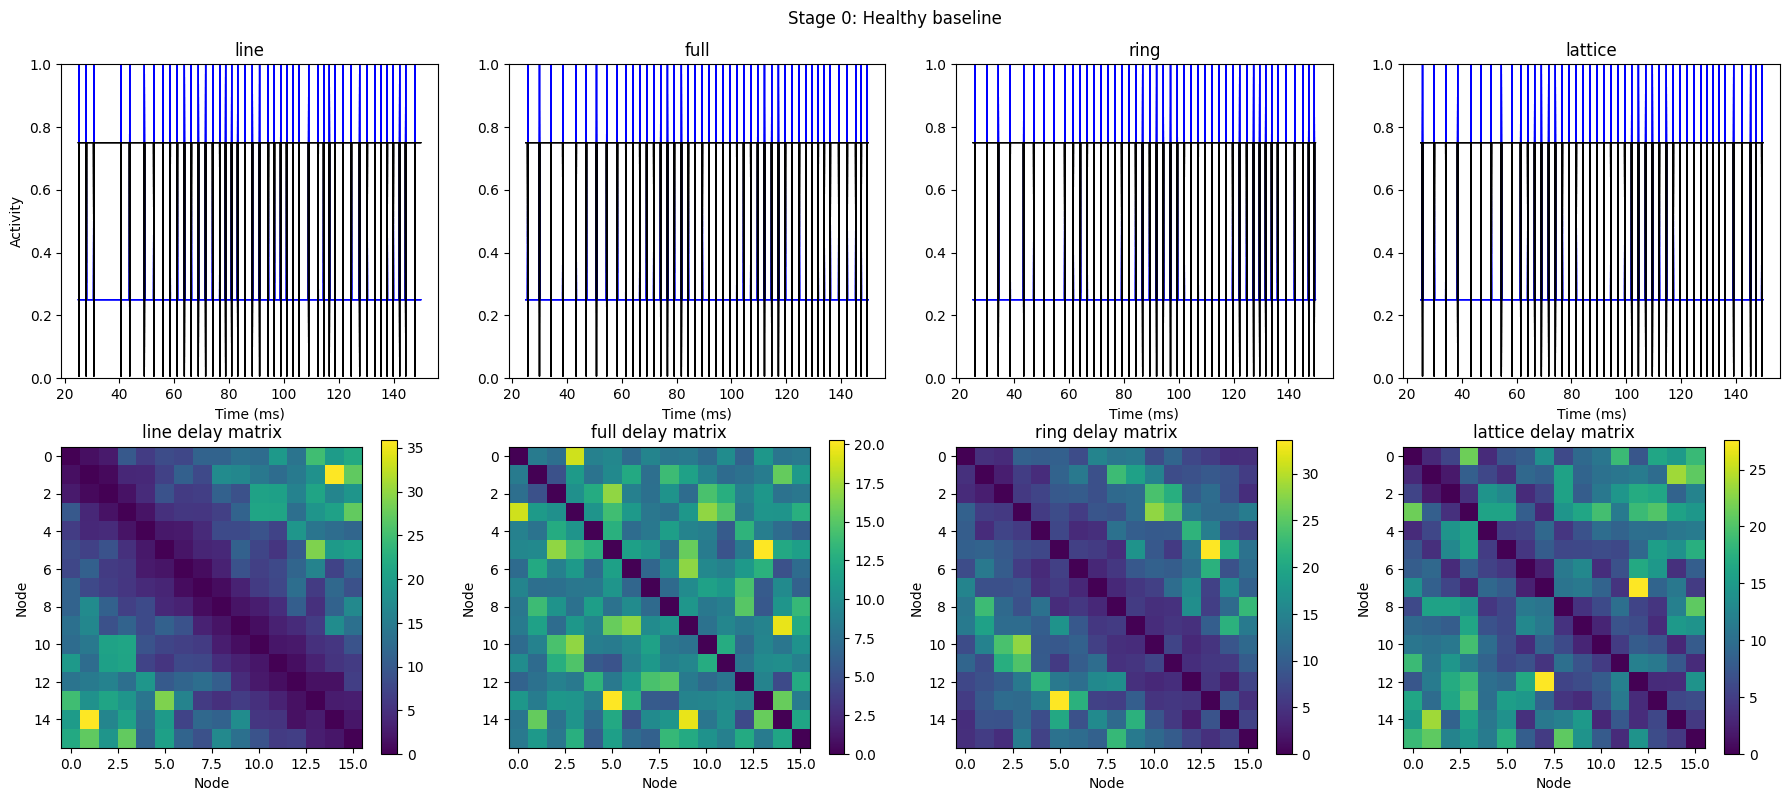

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,0,Healthy baseline,6.582123e-25,0.392308
1,full,0,Healthy baseline,0.000000e+00,1.584615
2,ring,0,Healthy baseline,0.000000e+00,1.584615
3,lattice,0,Healthy baseline,3.451266e-33,1.584615


In [10]:
plot_stage(results, 0)

df_stage0 = get_metrics_df(results, 0)
display(df_stage0)

### Stage 0 Observations

All four topologies show stable limit cycle oscillations at baseline, consistent with 
Conti & Van Gorder (2019). The full, ring and lattice topologies oscillate at ~1.585 Hz 
with near-perfect synchrony. The line topology shows lower frequency (0.392 Hz) and 
slightly higher asynchrony, reflecting its sparse connectivity and greater delay variance 
- a pattern consistent with our distance-based delay experiments.

The delay matrices confirm healthy structured myelination: topology is clearly readable 
from the delay structure, with smooth gradients and relatively low variance across edges.

## Stage 1: Early MS - Focal Demyelination

In early MS, focal demyelinating lesions begin to form. Individual axon tracts lose their 
myelin sheath in patches, reducing conduction velocity and increasing heterogeneity across 
the network. Crucially, axonal integrity is preserved at this stage - connectivity is unchanged.

We model this with:
- vm = 4.0 m/s (40% reduction from healthy, consistent with Waxman 2006)
- p = 4.5 (broader Gamma distribution, increased myelination heterogeneity)
- Full connectivity maintained

The key question at this stage: does focal demyelination alone - without any loss of 
connections - produce measurable changes in network oscillatory dynamics?

In [6]:
for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 1)] = run_stage(topology, 1)

print("Done.")

  line...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.32425458,  2.16599124,  4.31960076,  6.17847329,
         5.12133781,  8.90060276,  8.59976268, 10.28365878,  9.22215142,
        16.7949555 ,  9.76070861, 22.85061555, 15.50905743, 17.63556483,
        29.86394523],
       [ 1.32425458,  0.        ,  1.14912198,  3.24148117,  7.09199259,
         4.34561733, 14.48029571, 12.98039701, 10.13321344,  8.22217783,
        10.05770747, 13.33940877, 38.07924217, 23.36424709, 22.86020582,
        33.88295679],
       [ 2.16599124,  1.14912198,  0.        ,  4.01688039,  2.83202102,
         3.30524463,  7.30621999,  5.16862432, 18.52429775, 17.47055169,
        11.43868669, 17.12825942, 11.44219941, 13.58015236, 22.08262492,
        38.21644569],
       [ 4.31960076,  3.24148117,  4.01688039,  0.        ,  1.9460184 ,
         2.44233052,  3.37265081,  7.59672844, 20.14510018, 19.0738329

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  7.23788597,  5.91925371,  7.86978031,  8.44231276,
         5.59826786,  8.10790073,  6.71473196,  7.02583467,  5.60054117,
         9.17950182,  4.84985682, 10.40775145,  6.52052113,  6.88496272,
        10.88168566],
       [ 7.23788597,  0.        ,  6.28067593,  8.8583689 , 12.9207366 ,
         5.93788447, 15.82878868, 11.82434193,  7.91205696,  5.61742307,
         6.10796789,  7.29082772, 18.92064191, 10.64169479,  9.61118725,
        13.22797974],
       [ 5.91925371,  6.28067593,  0.        , 21.95478328,  7.73939   ,
         6.02174843,  9.98327439,  5.64995797, 16.87449394, 13.64108246,
         7.81495411, 10.40185935,  6.25388322,  6.74764479, 10.05795538,
        16.06745882],
       [ 7.86978031,  8.8583689 , 21.95478328,  0.        , 10.63621721,
         6.6744379 ,  6.14455419

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  4.20983197,  3.44286489,  4.57736594,  9.82074552,
         6.51233442,  9.43173181, 11.71663662, 12.2594844 ,  9.77246837,
        10.67830036,  5.64172532, 12.10709451,  3.79258507,  4.00455827,
         6.32920556],
       [ 4.20983197,  0.        ,  3.65308191,  5.15236696,  7.51519576,
         6.90740251, 18.41326068, 13.75498118, 13.80586698,  9.80192585,
        10.65788487,  8.48124983, 22.00994142, 12.37923535,  5.59023498,
         7.69390015],
       [ 3.44286489,  3.65308191,  0.        , 12.76974366,  4.50152593,
         3.50247975, 11.61331025,  6.57246433, 19.62970522, 23.80252958,
        13.63643076, 18.15036056,  7.27499648,  7.8493778 , 11.7001849 ,
         9.34545004],
       [ 4.57736594,  5.15236696, 12.76974366,  0.        ,  6.1864317 ,
         3.88210896,  3.57390829

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  2.70377741,  4.42238094,  8.81948167,  3.15370187,
         4.18256663,  9.08633775, 10.0333941 ,  5.24912748,  6.27639759,
        13.7163419 ,  9.0585382 , 11.66372752,  9.74319728, 12.85969877,
        24.38970935],
       [ 2.70377741,  0.        ,  2.34620299,  6.61824677,  9.65331476,
         2.21815016, 11.82597279, 13.25126787,  8.86686014,  4.19687783,
         6.84505904, 10.8942171 , 28.27190391, 11.92590244, 14.36138181,
        24.70715409],
       [ 4.42238094,  2.34620299,  0.        ,  8.20140678,  8.67335625,
         4.49895658,  3.72934195,  4.22118524, 25.21447599, 15.28724716,
         5.83869281, 11.65712438, 11.68097165, 10.08257362, 11.27171911,
        24.00857508],
       [ 8.81948167,  6.61824677,  8.20140678,  0.        , 15.89301845,
         7.47988894,  4.59070

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


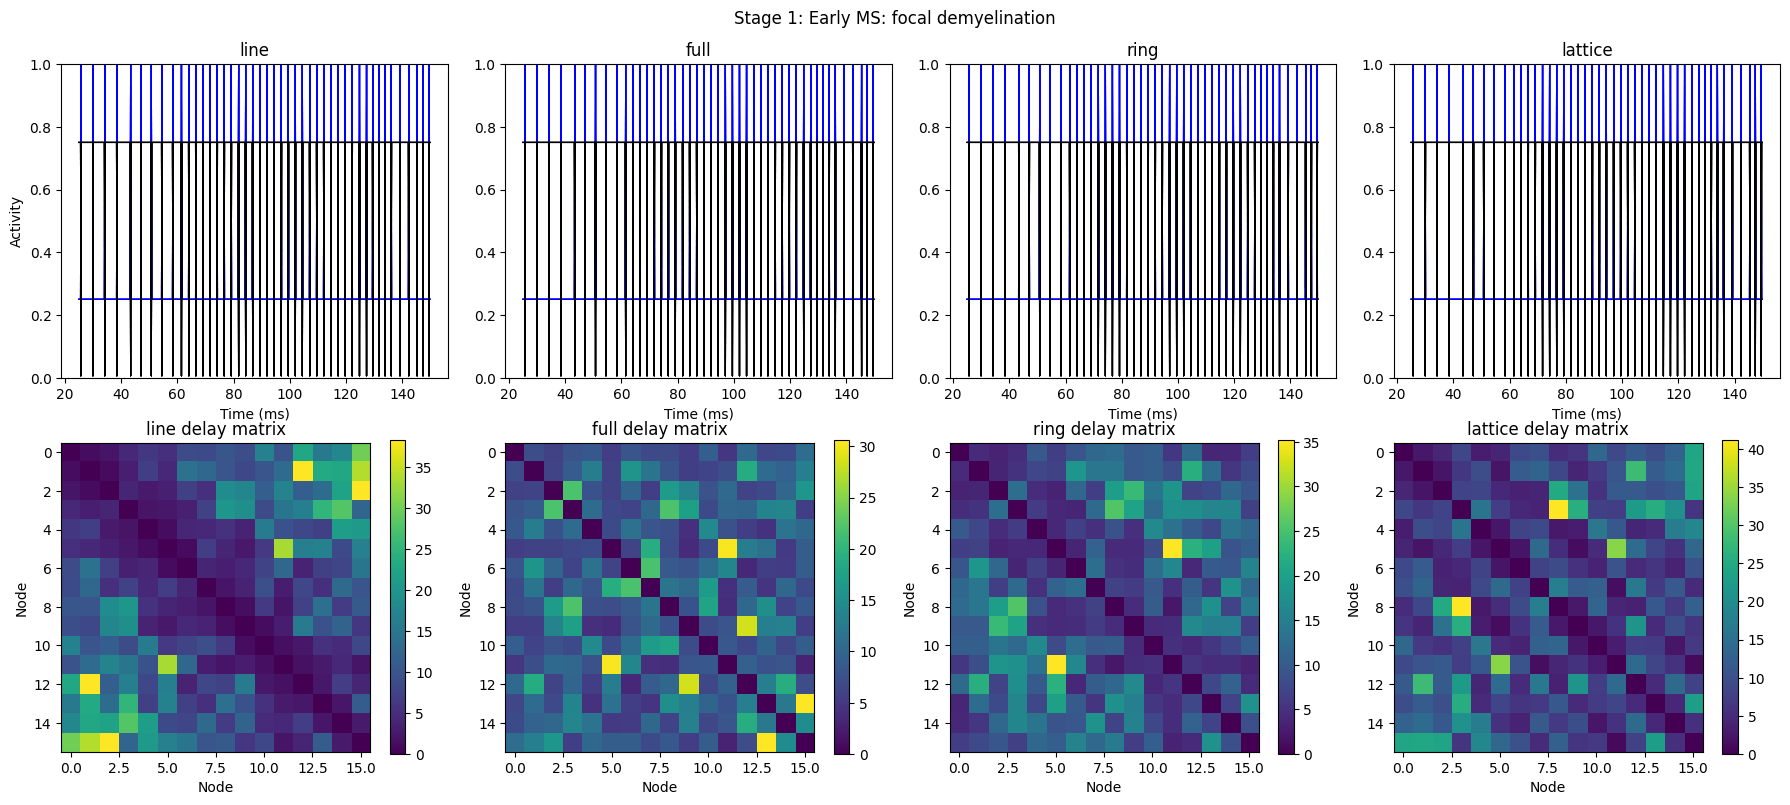

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,1,Early MS: focal demyelination,3.719724e-22,1.584615
1,full,1,Early MS: focal demyelination,0.000000e+00,1.584615
2,ring,1,Early MS: focal demyelination,0.000000e+00,1.584615
3,lattice,1,Early MS: focal demyelination,3.451266e-33,1.584615


In [9]:
plot_stage(results, 1)

df_stage1 = get_metrics_df(results, 1)
display(df_stage1)

### Stage 1 Observations

Early MS produces a notable change in the line topology: its dominant frequency shifts 
from 0.392 Hz to 1.585 Hz, aligning with the other topologies. Simultaneously, its 
synchrony index worsens by three orders of magnitude (6.58e-25 to 3.72e-22).

This is the first measurable effect of demyelination - the line topology, being the 
sparsest and most delay-sensitive, shows detectable dynamic changes even at the earliest 
MS stage. Dense topologies (full, ring, lattice) remain unaffected at this stage, 
suggesting they are more robust to early demyelination.

The delay matrices show increased random scatter compared to stage 0, reflecting the 
broader Gamma distribution (p=4.5 vs p=10). The underlying topology is still partially 
readable but disrupted.

## Stage 2: Moderate MS - Widespread Demyelination

As MS progresses, demyelination becomes more widespread across the network. More axon 
tracts are affected, further reducing mean conduction velocity and increasing heterogeneity. 
Axonal integrity is still largely preserved at this stage, but the myelination landscape 
is severely disrupted.

We model this with:
- vm = 2.0 m/s (67% reduction from healthy baseline)
- p = 2.5 (broad Gamma distribution, high heterogeneity - some tracts very slow, some fast)
- Full connectivity maintained

Key question: does widespread demyelination begin to affect the previously robust 
dense topologies, or do they continue to resist dynamic disruption?

In [11]:
for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 2)] = run_stage(topology, 2)

print("Done.")

  line...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.33175303,  2.03187866,  4.48023657,  6.58247533,
         4.71756858,  9.33632889,  8.42070563, 10.23196846,  8.49618421,
        18.49609188,  8.59675642, 26.51408121, 15.03207609, 17.42109464,
        35.32623562],
       [ 1.33175303,  0.        ,  1.0995855 ,  3.51927894,  9.07287271,
         4.08078796, 20.505336  , 15.934677  , 10.53125611,  7.58229143,
         9.53404591, 13.45041789, 25.0898802 , 23.67895583, 40.70566065,
        20.43313508],
       [ 2.03187866,  1.0995855 ,  0.        ,  1.03943532,  4.16459068,
         2.86517392, 18.09693897, 16.38742796,  8.87473488, 15.45404324,
         8.74647031, 10.89833003, 21.04459393, 46.15547035, 27.35059454,
        15.51196704],
       [ 4.48023657,  3.51927894,  1.03943532,  0.        ,  1.06782219,
         4.40233449,  3.76330886,  8.51268754, 10.4695883 , 19.9058740

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  7.42166143,  5.66167867,  8.32256385,  9.17078882,
         5.2580615 ,  8.67166187,  6.70390559,  7.12765466,  5.26088555,
        10.3075967 ,  4.35531308, 12.31325234,  6.44396328,  6.93465481,
        13.12452353],
       [ 7.42166143,  0.        ,  6.12782632,  9.80620886, 16.85392306,
         5.68540597, 22.85463708, 14.80026385,  8.3841604 ,  5.2818727 ,
         5.90353542,  7.49571769, 12.71110617, 10.99660803, 17.44973754,
         8.13363003],
       [ 5.66167867,  6.12782632,  0.        ,  5.7926183 , 11.604322  ,
         5.32239593, 25.21288681, 18.26493936,  8.24292942, 12.30329753,
         6.09284714,  6.7483079 , 11.72783896, 23.38341511, 12.7017327 ,
         6.64968334],
       [ 8.32256385,  9.80620886,  5.7926183 ,  0.        ,  5.95081411,
        12.26677742,  6.99078672

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  4.18687354,  3.19399273,  4.69511075, 10.34726076,
         5.93259038,  9.78410346, 11.34587121, 12.06303561,  8.90366506,
        11.62990371,  4.91403314, 13.8928543 ,  3.6353126 ,  3.91213248,
         7.40409959],
       [ 4.18687354,  0.        ,  3.45696636,  5.53209774,  9.50801181,
         6.4147566 , 25.78653747, 16.69891135, 14.18957992,  8.93918427,
         9.99130308,  8.45730363, 14.34174668, 12.40730465,  9.84413599,
         4.58852518],
       [ 3.19399273,  3.45696636,  0.        ,  3.26786132,  6.54648952,
         3.00258896, 28.44731458, 20.60805174,  9.3003712 , 20.82243365,
        10.31169937, 11.42101889, 13.23234133, 26.38314964, 14.33117074,
         3.75136801],
       [ 4.69511075,  5.53209774,  3.26786132,  0.        ,  3.35710627,
         6.92020868,  3.94379887

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  2.77822345,  4.23878361,  9.34640131,  3.43299149,
         3.93660365,  9.73844518, 10.0381554 ,  5.33633001,  5.90807694,
        15.43417581,  8.15183571, 13.82802221,  9.64892836, 12.97958737,
        29.47819111],
       [ 2.77822345,  0.        ,  2.29388944,  7.34170903, 12.61818924,
         2.12827388, 17.11080172, 16.62098458,  9.41557543,  3.95443061,
         6.62978526, 11.22378261, 19.03309307, 12.349405  , 26.12852683,
        15.22370824],
       [ 4.23878361,  2.29388944,  0.        ,  2.16840772, 13.03187962,
         3.98476953,  9.43818766, 13.67458844, 12.34262706, 13.81684276,
         4.56159068,  7.57848121, 21.95098596, 35.01337416, 14.26429321,
         9.95696521],
       [ 9.34640131,  7.34170903,  2.16840772,  0.        ,  8.91050687,
        13.77582997,  5.23385

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


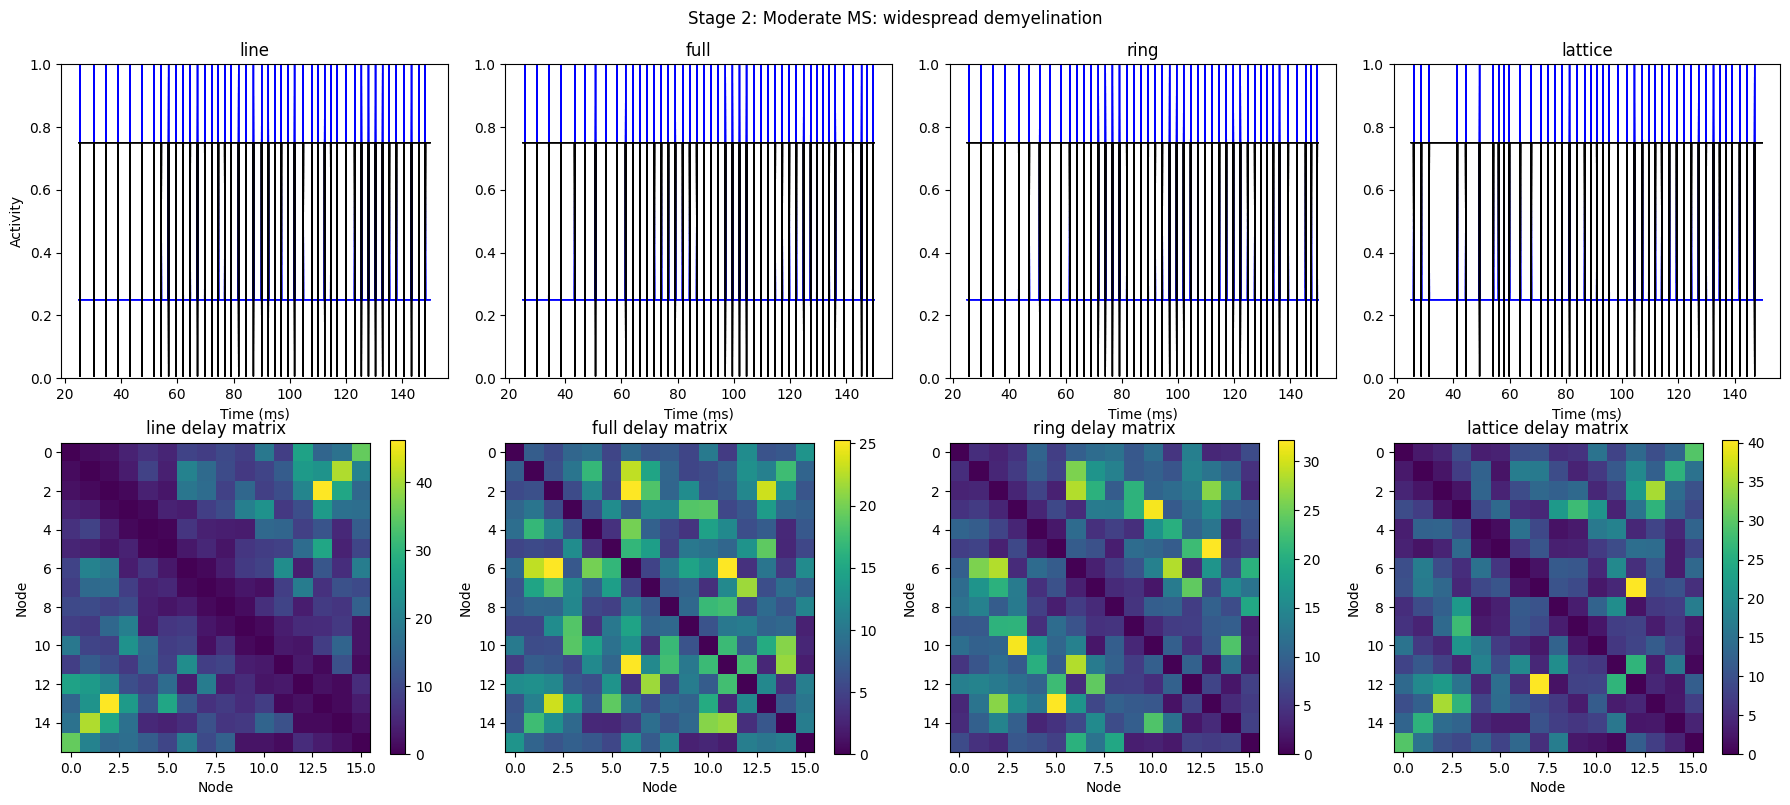

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,2,Moderate MS: widespread demyelination,6.868101e-25,0.392308
1,full,2,Moderate MS: widespread demyelination,0.000000e+00,1.584615
2,ring,2,Moderate MS: widespread demyelination,0.000000e+00,1.584615
3,lattice,2,Moderate MS: widespread demyelination,3.185784e-33,3.207692


In [12]:
plot_stage(results, 2)

df_stage2 = get_metrics_df(results, 2)
display(df_stage2)

### Stage 2 Observations

Moderate MS produces divergent effects across topologies. The full and ring topologies 
remain completely unaffected, suggesting high connectivity provides strong robustness 
against demyelination-driven heterogeneity.

The lattice topology shows its first dynamic disruption - dominant frequency doubles 
from 1.585 Hz to 3.208 Hz. This is notable because lattice connectivity is intermediate 
between line and full, suggesting a threshold exists between stages 1 and 2 at which 
moderately connected networks become vulnerable.

Unexpectedly, the line topology partially recovers toward its stage 0 state. This may 
reflect a non-linear interaction between delay heterogeneity and the sparse coupling 
structure of the line - at very high heterogeneity, some delay combinations may 
accidentally reinforce the natural oscillation frequency.

The delay matrices confirm topology structure is now largely unreadable - widespread 
demyelination has disrupted the organised delay landscape of the healthy brain.

## Stage 3: Severe MS - Axonal Loss

In progressive MS, demyelination is accompanied by irreversible axonal loss. Axons 
are permanently severed, removing connections from the network entirely. This is the 
stage associated with the most severe and irreversible clinical disability.

We model this with:
- vm = 2.0 m/s (same as stage 2 - demyelination unchanged)
- p = 2.5 (same as stage 2 - high heterogeneity unchanged)
- Edge removal to simulate axonal loss:
  - Line: 0% (network too sparse - any removal fragments it, itself a finding)
  - Full: 30% random removal
  - Ring: 20% random removal
  - Lattice: 25% random removal

The line topology's inability to tolerate any axonal loss is biologically meaningful - 
sparse networks are disproportionately vulnerable to connectivity loss, consistent with 
the paper's discussion of neurodegenerative disease effects on sparse networks.

In [13]:
for topology in TOPOLOGIES:
    print(f"  {topology}...")
    results[(topology, 3)] = run_stage(topology, 3)

print("Done.")

  line...
  line: removed 0 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.33175303,  2.03187866,  4.48023657,  6.58247533,
         4.71756858,  9.33632889,  8.42070563, 10.23196846,  8.49618421,
        18.49609188,  8.59675642, 26.51408121, 15.03207609, 17.42109464,
        35.32623562],
       [ 1.33175303,  0.        ,  1.0995855 ,  3.51927894,  9.07287271,
         4.08078796, 20.505336  , 15.934677  , 10.53125611,  7.58229143,
         9.53404591, 13.45041789, 25.0898802 , 23.67895583, 40.70566065,
        20.43313508],
       [ 2.03187866,  1.0995855 ,  0.        ,  1.03943532,  4.16459068,
         2.86517392, 18.09693897, 16.38742796,  8.87473488, 15.45404324,
         8.74647031, 10.89833003, 21.04459393, 46.15547035, 27.35059454,
        15.51196704],
       [ 4.48023657,  3.51927894,  1.03943532,  0.        ,  1.06782219,
         4.40233449,  3.76330886,  8.51268754,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  full...
  full: removed 36 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  5.62593665,  4.29179447,  6.3088592 ,  6.95184998,
         3.98583541,  6.57349042,  5.08184703, 10.80613389,  7.97595231,
         7.81359896,  6.60302702,  9.33397168,  4.88479965, 10.51352962,
         9.94894992],
       [ 5.62593665,  0.        ,  4.64515432,  7.43352554, 12.7759942 ,
         8.61956156, 34.64958393, 11.21923273,  6.35555201,  4.00388531,
         4.47513223,  5.68207446,  9.63556189, 16.671798  , 13.22764704,
         6.16563928],
       [ 4.29179447,  4.64515432,  0.        ,  4.39105231,  8.79657217,
         4.03460365, 19.11244608, 13.84560488,  6.2484929 ,  9.32642551,
         4.61863861,  5.11550589, 17.78040661, 35.45125664,  9.6284564 ,
         5.04074425],
       [ 6.3088592 ,  7.43352554,  4.39105231,  0.        ,  4.5109715 ,
       

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  ring...
  ring: removed 9 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  7.74312622,  2.95345543,  4.34152534,  9.568016  ,
         5.48581127,  9.04726968, 10.49142182, 11.15457708,  8.23313646,
        16.13109605,  4.54396084, 12.84659344,  3.36153983,  3.6175126 ,
         6.84650218],
       [ 7.74312622,  0.        ,  3.19662471, 10.23095888,  8.79197029,
         5.9316659 , 35.76685786, 15.44132836, 13.12097288,  8.26598074,
         9.23886524,  7.82039018, 13.26168007, 11.47291947,  9.1027812 ,
         4.24296666],
       [ 2.95345543,  3.19662471,  0.        ,  3.02176103,  6.0534781 ,
         2.77646615, 26.3049678 , 19.0560742 ,  8.59996694, 19.25431117,
         9.53513271, 10.56091019, 12.23582323, 24.39625364, 13.25190059,
         3.46885518],
       [ 4.34152534, 10.23095888,  3.02176103,  0.        ,  3.10428502,
        

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
  lattice...
  lattice: removed 6 edges
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  7.39996529,  7.52683677, 13.83039009,  3.04799312,
         3.49512689,  8.64631154,  8.91241027,  4.73787867,  8.74251021,
        13.70328527,  7.23763494, 12.27725635,  8.56683372, 11.52397061,
        26.17231181],
       [ 7.39996529,  0.        ,  2.0366375 ,  6.51836123, 11.20310206,
         1.88959517, 15.19188326, 14.75699745,  8.35965053,  7.02190922,
         5.88627729,  9.96507341, 16.89859615, 18.27410176, 23.19830104,
        13.51642092],
       [ 7.52683677,  2.0366375 ,  0.        ,  1.92522814, 11.57039846,
         3.53789112,  8.37972688, 12.14102966, 10.95844323, 12.26733064,
         4.05002373,  6.72858021, 19.48925723, 31.08674283, 12.66460104,
         8.84032529],
       [13.83039009,  6.51836123,  1.92522814,  0.        ,  7.9112237 ,
  

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Done.


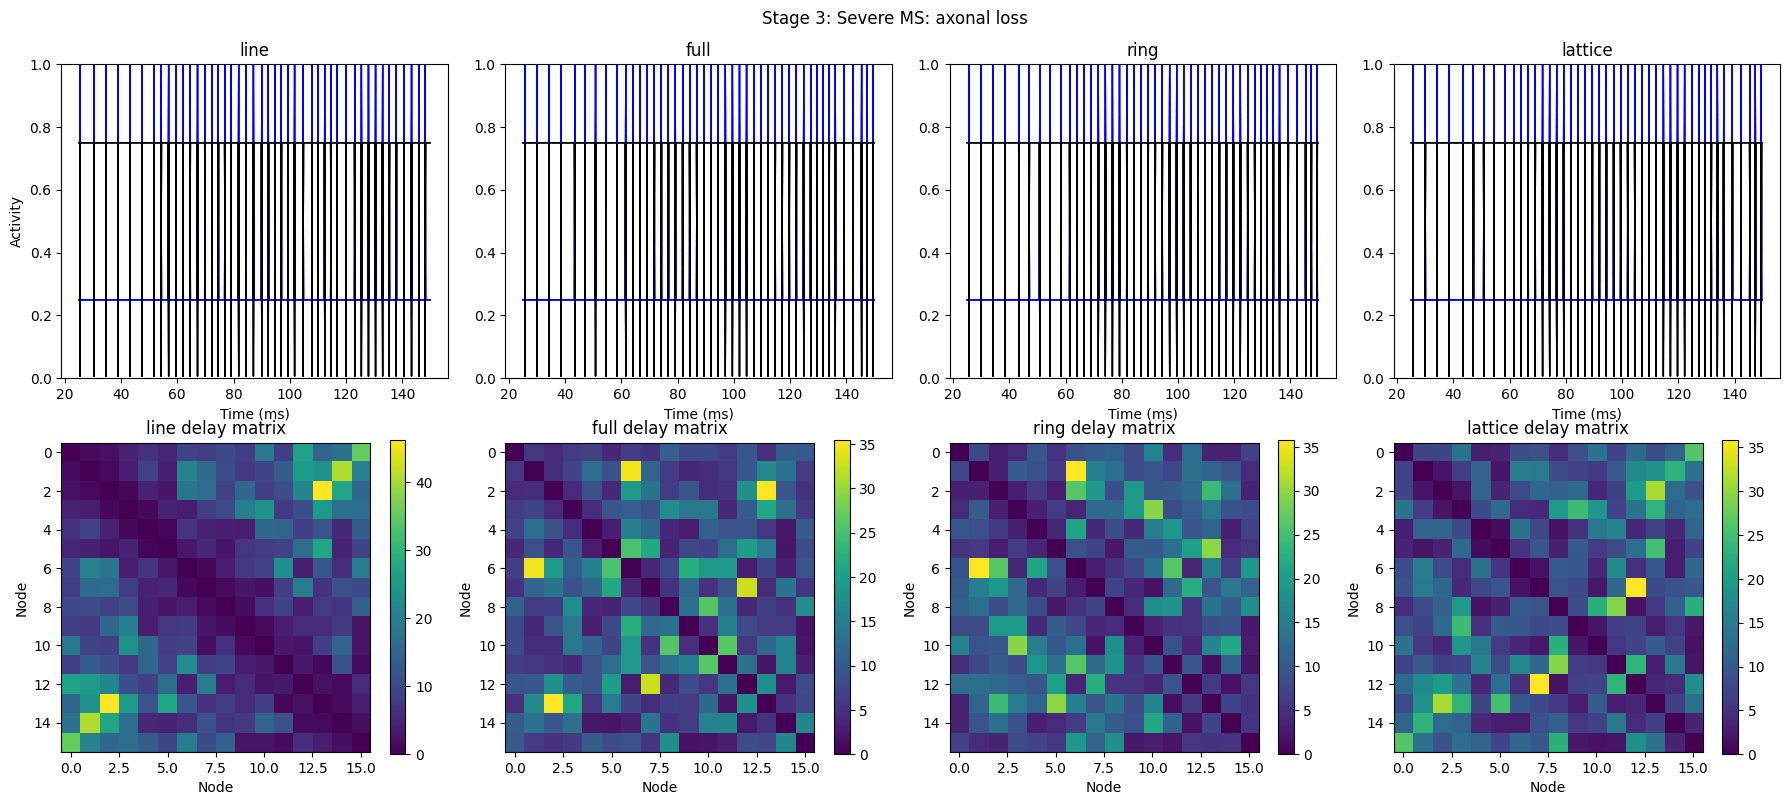

,Topology,Stage,Description,Synchrony,Frequency (Hz)
0,line,3,Severe MS: axonal loss,6.868101e-25,0.392308
1,full,3,Severe MS: axonal loss,0.000000e+00,1.584615
2,ring,3,Severe MS: axonal loss,0.000000e+00,1.584615
3,lattice,3,Severe MS: axonal loss,3.503758e-21,1.584615


In [14]:
plot_stage(results, 3)

df_stage3 = get_metrics_df(results, 3)
display(df_stage3)

### Stage 3 Observations

Severe MS with axonal loss produces divergent effects across topologies.

Full and ring topologies show complete resilience even after 30% and 20% axonal loss 
respectively. This suggests dense, homogeneous networks can compensate for significant 
connectivity loss without dynamic disruption - consistent with the redundancy principle 
in network neuroscience.

The lattice topology shows a dissociation between frequency and synchrony: frequency 
returns to baseline (1.585 Hz) but synchrony worsens significantly (3.50e-21 vs 
3.19e-33 at baseline). Axonal loss appears to disrupt the coordinated timing of 
oscillations without altering their frequency - a subtle but potentially clinically 
relevant signature of connectivity loss.

The line topology is unchanged from stage 2, as no edges could be removed without 
fragmentation. This itself is a finding: sparse networks are so vulnerable to 
connectivity loss that even minimal axonal loss (>0%) would destroy network integrity.

,Stage,Topology,Description,Synchrony,Frequency (Hz)
0,0,line,Healthy baseline,6.582123e-25,0.392308
1,0,full,Healthy baseline,0.000000e+00,1.584615
2,0,ring,Healthy baseline,0.000000e+00,1.584615
3,0,lattice,Healthy baseline,3.451266e-33,1.584615
4,1,line,Early MS: focal demyelination,3.719724e-22,1.584615
5,1,full,Early MS: focal demyelination,0.000000e+00,1.584615
6,1,ring,Early MS: focal demyelination,0.000000e+00,1.584615
7,1,lattice,Early MS: focal demyelination,3.451266e-33,1.584615
8,2,line,Moderate MS: widespread demyelination,6.868101e-25,0.392308
9,2,full,Moderate MS: widespread demyelination,0.000000e+00,1.584615


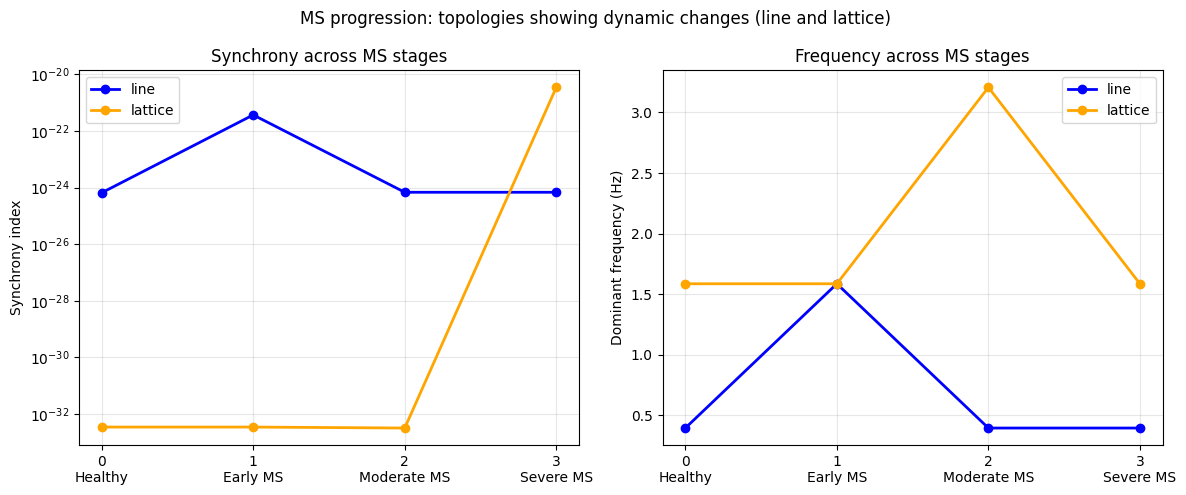

In [20]:
# Collect all metrics
all_metrics = []
for stage in range(4):
    for topology in TOPOLOGIES:
        m = results[(topology, stage)]
        all_metrics.append({
            'Stage': stage,
            'Topology': topology,
            'Description': MS_STAGES[stage]['description'],
            'Synchrony': get_synchrony(m.model.trajectories, m.model.time_array),
            'Frequency (Hz)': get_frequency(m.model.trajectories, m.model.time_array)
        })

df_all = pd.DataFrame(all_metrics)
display(df_all)

# Plot only topologies showing dynamic changes
CHANGING_TOPOLOGIES = ['line', 'lattice']
colors = {'line': 'blue', 'full': 'red', 'ring': 'green', 'lattice': 'orange'}
stages = [0, 1, 2, 3]
stage_labels = ['0\nHealthy', '1\nEarly MS', '2\nModerate MS', '3\nSevere MS']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("MS progression: topologies showing dynamic changes (line and lattice)")

for topology in CHANGING_TOPOLOGIES:
    df_topo = df_all[df_all['Topology'] == topology].sort_values('Stage')
    sync_vals = df_topo['Synchrony'].values
    freq_vals = df_topo['Frequency (Hz)'].values
    
    axes[0].plot(stages, sync_vals, 'o-', color=colors[topology],
                label=topology, linewidth=2, markersize=6)
    axes[1].plot(stages, freq_vals, 'o-', color=colors[topology],
                label=topology, linewidth=2, markersize=6)

axes[0].set_xticks(stages)
axes[0].set_xticklabels(stage_labels)
axes[0].set_ylabel("Synchrony index")
axes[0].set_title("Synchrony across MS stages")
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xticks(stages)
axes[1].set_xticklabels(stage_labels)
axes[1].set_ylabel("Dominant frequency (Hz)")
axes[1].set_title("Frequency across MS stages")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ms_progression_comparison.png", dpi=150)
plt.show()

### Cross-Stage Comparison Observations

Full and ring topologies showed no measurable dynamic changes across all four MS stages, 
demonstrating complete robustness to both demyelination and axonal loss. Their high 
connectivity provides sufficient redundancy to absorb progressive MS-related damage.

Line and lattice show distinct vulnerability signatures:

**Line topology** is most sensitive to early demyelination (stage 1), showing peak 
asynchrony and frequency shift. It partially recovers at moderate MS (stage 2), 
suggesting a non-linear interaction between delay heterogeneity and sparse connectivity.

**Lattice topology** is resilient to demyelination alone (stages 1-2) but shows dramatic 
synchrony degradation under axonal loss (stage 3). This dissociation between demyelination 
and axonal loss effects suggests intermediate connectivity networks have a specific 
vulnerability threshold for structural damage.

These findings suggest network topology is a key determinant of MS vulnerability - 
sparse networks (line) show early functional changes, while intermediate networks 
(lattice) show late structural sensitivity.

## Conclusions

This notebook modelled MS disease progression through four stages using the Wilson-Cowan 
metapopulation framework with heterogeneous delay structure. The key findings are:

### 1. Network topology determines MS vulnerability profile
- **Full and ring** topologies (high connectivity, homogeneous degree) showed complete 
  robustness across all MS stages - no measurable dynamic changes under demyelination 
  or axonal loss
- **Line** topology (sparse, heterogeneous degree) showed early vulnerability - detectable 
  changes from stage 1 onwards
- **Lattice** topology (intermediate connectivity) showed a specific vulnerability to 
  axonal loss at stage 3, but resilience to demyelination alone

### 2. Demyelination and axonal loss produce distinct dynamic signatures
- Demyelination primarily affects **frequency** - the line topology shows frequency shifts 
  under early and moderate MS
- Axonal loss primarily affects **synchrony** - the lattice topology shows dramatic 
  synchrony degradation only when edges are removed
- This dissociation suggests different clinical measurement strategies may be needed 
  to detect early vs late MS

### 3. Sparse networks are disproportionately vulnerable
- The line topology could not tolerate any axonal loss without fragmentation
- This is consistent with Conti & Van Gorder (2019) who showed sparse networks are 
  more susceptible to deregularisation
- Clinically, this may relate to the observation that white matter tracts with fewer 
  redundant pathways show earlier and more severe MS-related damage

### 4. Delay heterogeneity as an early biomarker
- The delay matrices showed progressive loss of topology-readable structure across stages
- By stage 2, delay matrices were largely unreadable - the organised signal transmission 
  structure of the healthy brain was disrupted
- This suggests conduction velocity heterogeneity, measurable through techniques like 
  diffusion tensor imaging, could serve as an early biomarker of MS-related network 
  disruption

### Limitations
- N=16 nodes is small - larger networks may show different vulnerability thresholds
- A single realisation of random axonal loss was used for stage 3 - averaging over 
  multiple realisations would give more robust results
- The model uses abstract graph topologies rather than realistic connectome data
- Parameters are from rodent data (Atay & Hutt, 2006) - human cortico-cortical 
  conduction velocities may differ

### Future directions
- Use realistic human connectome data for network structure
- Average stage 3 results over multiple random edge removal realisations
- Extend to larger N to test whether vulnerability thresholds shift
- Compare with clinical MS progression data